In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [31]:
#load dataset
df=pd.read_csv('/content/fake_bills.csv', sep=';')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 1 columns):
 #   Column                                                                    Non-Null Count  Dtype 
---  ------                                                                    --------------  ----- 
 0   is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length  1500 non-null   object
dtypes: object(1)
memory usage: 11.8+ KB


In [26]:
df.describe()

,is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length
count,1500
unique,1500
top,False;171.47;104.15;103.82;4.63;3.37;112.07
freq,1


In [27]:
df.shape

(1500, 1)

In [28]:
df.isnull().sum()

,0
is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length,0


In [29]:
print("No.of records:",df.duplicated().sum())

No.of records: 0


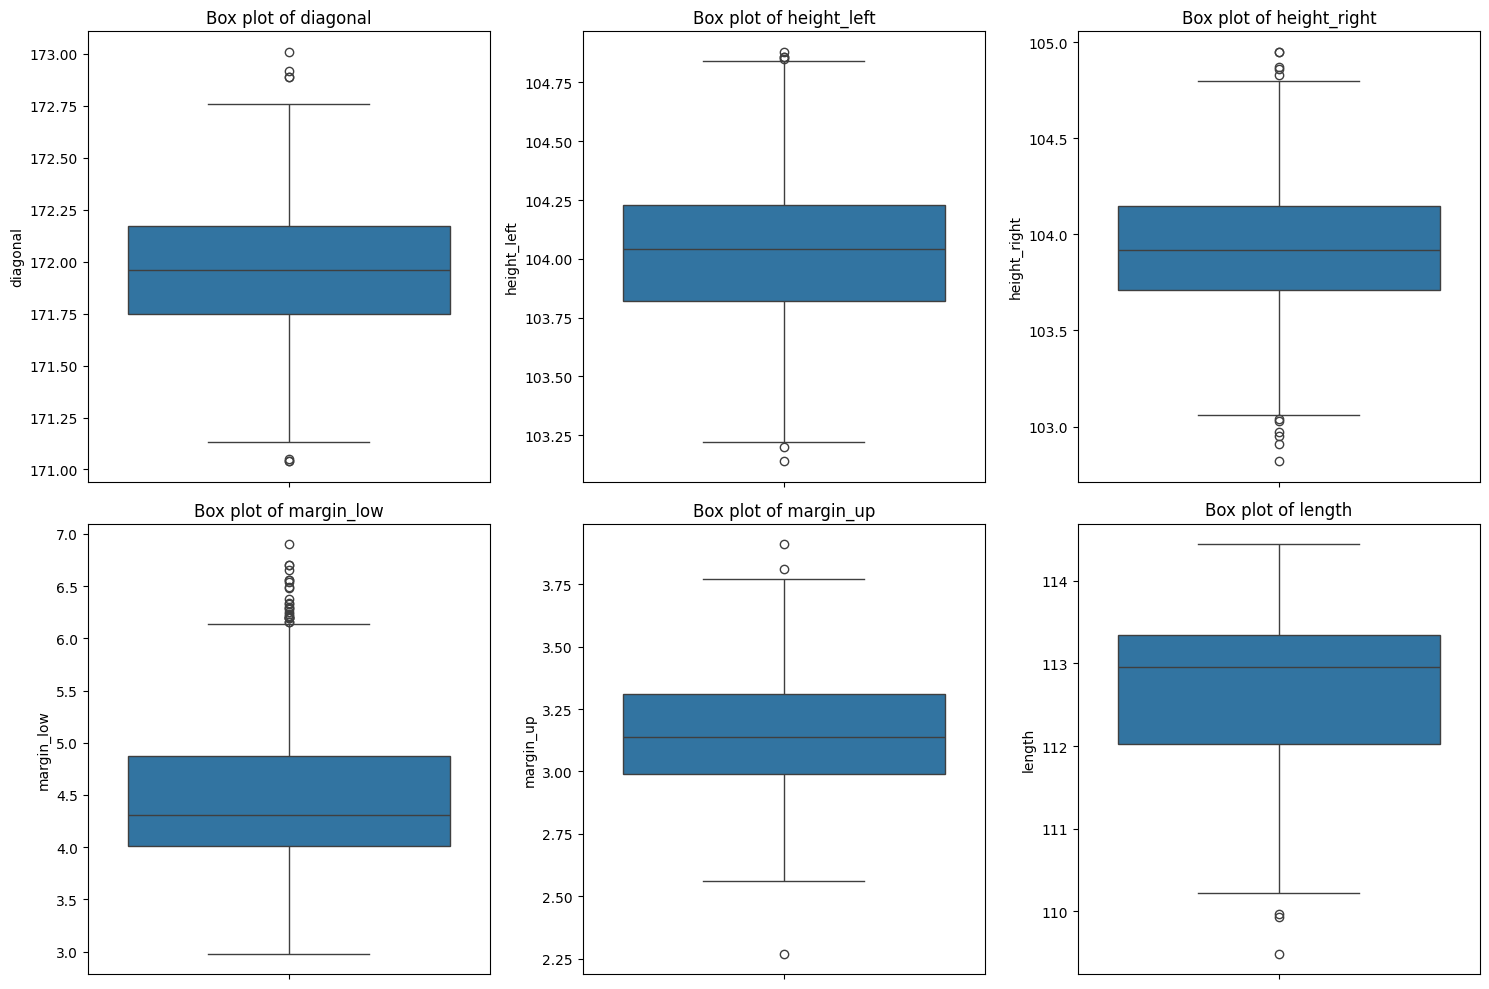

In [33]:
# Identify numerical columns for outlier analysis
numerical_cols = df.select_dtypes(include=np.number).columns
# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [34]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
# Remove outliers from all numerical columns using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

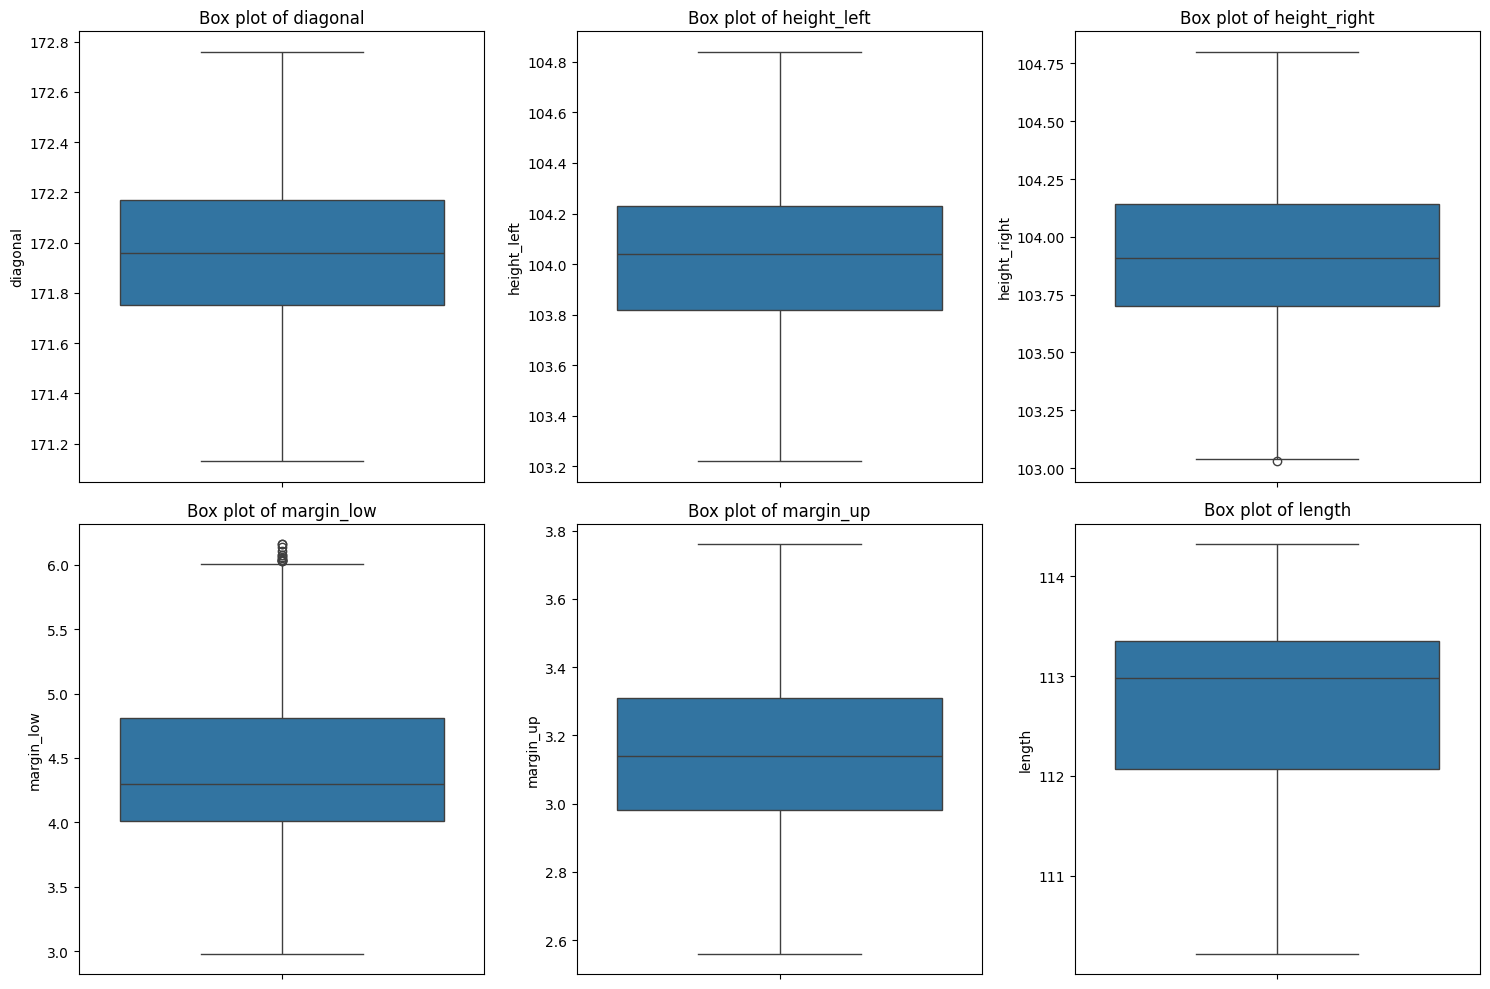

In [36]:
# Identify numerical columns for outlier analysis
numerical_cols = df.select_dtypes(include=np.number).columns
# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [40]:
#label encoding for target
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['is_genuine']=le.fit_transform(df['is_genuine'])
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1,1,171.46,103.36,103.66,3.77,2.99,113.09
2,1,172.69,104.48,103.50,4.40,2.94,113.16
3,1,171.36,103.91,103.94,3.62,3.01,113.51
4,1,171.73,104.28,103.46,4.04,3.48,112.54
5,1,172.17,103.74,104.08,4.42,2.95,112.81


In [45]:
y=df['is_genuine']
x=df.drop('is_genuine', axis=1)

In [46]:
#split the data into training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=15)

In [47]:
#satndardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [48]:
#model building
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [49]:
#predictions on test data
y_pred=knn.predict(x_test)

In [50]:
#evaluation metrics
accuracy_score(y_test,y_pred)
classification_report(y_test,y_pred)
confusion_matrix(y_test,y_pred)

array([[ 91,   1],
       [  2, 187]])

<Axes: >

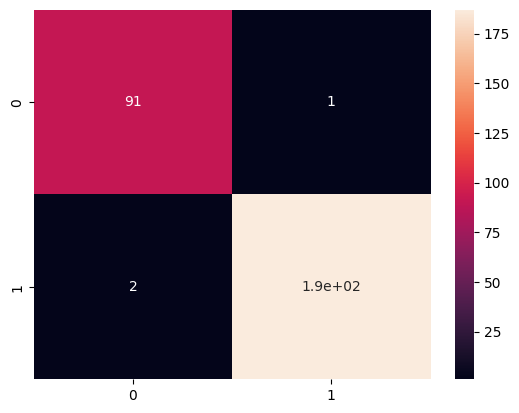

In [51]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [53]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(
y_test,
y_proba[:, 1], # Pass probabilities of the positive class (class 1)
multi_class='ovr'
)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.9893238434163701
ROC-AUC Score: 0.9970669427191166


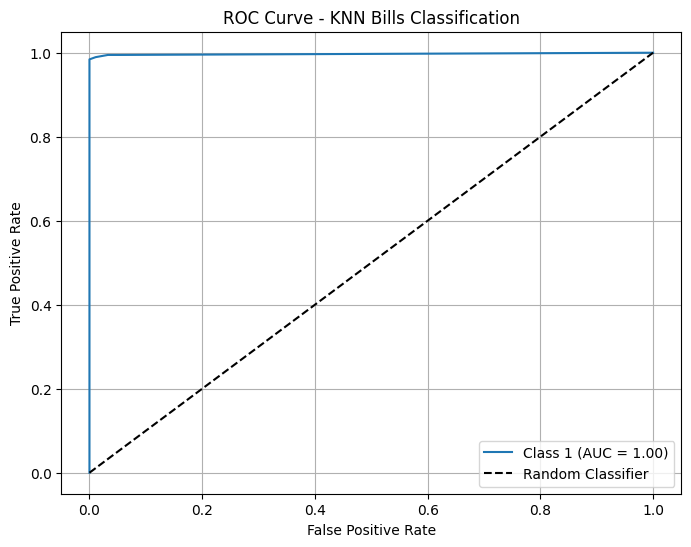

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_proba = knn.predict_proba(x_test)

plt.figure(figsize=(8, 6))

# For binary classification, we plot the ROC curve for the positive class (class 1).
# y_test already contains the binary true labels (0 or 1).
# y_proba[:, 1] contains the probabilities of the positive class (class 1).
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
auc_score = roc_auc_score(y_test, y_proba[:, 1])
plt.plot(fpr, tpr, label=f'Class 1 (AUC = {auc_score:.2f})')

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Bills Classification')
plt.legend()
plt.grid()
plt.show()

In [59]:
overall_auc = roc_auc_score(y_test, y_proba[:, 1])
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.9970669427191166
